# Prophet


## Введение

В этой лекции мы познакомимся с [Prophet](https://facebook.github.io/prophet/), фреймворком для прогнозирования временных рядов, разработанным компанией Meta (бывший Facebook) в 2017 году.

- Prophet основан на *аддитивной модели*, в которой нелинейные тренды аппроксимируются с учетом годовой, недельной и суточной сезонности, а также влияния праздников.

- Он лучше всего работает с временными рядами, имеющими сильные сезонные эффекты и несколько сезонов исторических данных.

- Prophet устойчив к отсутствующим данным, сдвигам тренда и, как правило, хорошо справляется с выбросами.

Далее мы рассмотрим:

- Основные компоненты модели Prophet: тренд, сезонность и праздники.

- Как использовать библиотеку Prophet в Python для прогнозирования временных рядов.

- Опробуем более продвинутые параметры и конфигурации, доступные в библиотеке Python.

In [1]:
# Imports
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm

---

## Model components

- Модель Prophet моделирует временной ряд $y(t)$ как комбинацию трех компонентов:

1. тренд $g(t)$,

2. сезонность $s(t)$,

3. праздники $h(t)$.

— Модельное уравнение имеет вид:

$$y(t) = g(t) + s(t) + h(t) + \epsilon_t$$

— где $\epsilon_t$ — член ошибки, который, как предполагается, имеет нормальное распределение.

### Компонент тренда $g(t)$

- Компонент тренда моделирует непериодические изменения значения временного ряда.

Prophet предоставляет два варианта моделирования тренда:

- Модель кусочно-линейного роста.

- Модель логистического роста.

#### Кусочно-линейная модель роста

- Кусочно-линейная функция позволяет учитывать изменения направления тренда во времени.

- Это особенно полезно для временных рядов, демонстрирующих сдвиги темпов роста из-за внешних факторов или внутренних изменений.

- Это позволяет выявлять и прогнозировать тренды временных рядов, которые не следуют определенной форме (линейной или логистической).

- В модели кусочно-линейного тренда временной ряд делится на *сегменты*.

- В каждом сегменте тренд моделируется как линейная функция.

- Точки, где тренд меняет направление, называются *точками изменения*.

- Prophet позволяет пользователям указать *максимальное количество* потенциальных точек изменения или позволить алгоритму автоматически оценить их на основе данных.

- Prophet автоматически определяет точки изменения, позволяя тренду корректировать свой наклон в этих точках, тем самым фиксируя изменения направления тренда.

- Пользователи могут регулировать гибкость модели в отслеживании изменений тренда, настраивая параметр *предварительного масштаба* точки изменения.

     - Более высокий предварительный масштаб делает модель более чувствительной к изменениям (обеспечивая большую гибкость).

     - Более низкий предварительный масштаб делает модель менее чувствительной к колебаниям (что приводит к более плавному тренду).

Модель кусочно-линейного тренда в Prophet определяется следующим образом:

$$g(t) = (k + a(t)^\top \delta) \cdot t + (g_0 + a(t)^\top \gamma)$$

где:
- $g(t)$ — компонент тренда в момент времени $t$,
- $k$ — начальная скорость роста,
- $a(t)$ — вектор, каждый элемент которого:
- количество времени, прошедшее с соответствующей точки изменения, если $t$ находится после точки изменения;
- 0 в противном случае.
- $\delta$ представляет собой корректировку скорости роста в каждой точке изменения,
- $g_0$ — смещение (пересечение), т.е. значение при $t=0$,
- $\gamma$ компенсирует разрывы в тренде в каждой точке изменения, обеспечивая непрерывность тренда.

In [2]:
def compute_a(t, change_points):
    return np.array([max(0, t - cp) for cp in change_points])

def compute_g(t, k, delta, g0, gamma, change_points):
    a_t = compute_a(t, change_points)
    trend = (k + np.dot(a_t, delta)) * t + (g0 + np.dot(a_t, gamma))
    return trend

In [3]:
change_points = [3, 7, 11]           # Times at which changes occur
k = 0.3                              # Initial growth rate
delta = np.array([0.1, -0.2, -0.1])  # Adjustments to growth rate
g0 = 4.0                             # Initial offset
gamma = np.array([0.3, -0.1, 0.1])   # Compensations for discontinuities

time_points = np.linspace(0, 15, 200)
g_values = [compute_g(t, k, delta, g0, gamma, change_points) for t in time_points]

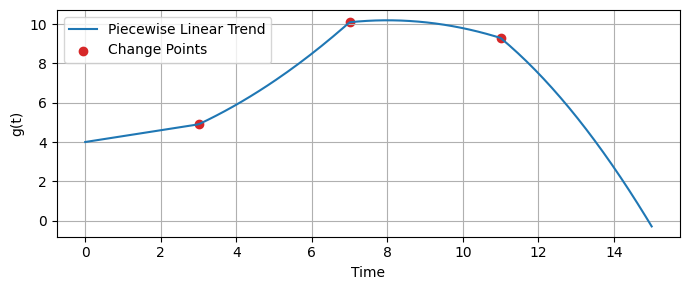

In [4]:
plt.figure(figsize=(7, 3))
plt.plot(time_points, g_values, label="Piecewise Linear Trend")
plt.scatter(change_points, [compute_g(cp, k, delta, g0, gamma, change_points) for cp in change_points], color='tab:red', label="Change Points")
plt.xlabel("Time")
plt.ylabel("g(t)")
plt.legend()
plt.grid(True)
plt.tight_layout();

**🛠️ Попробуйте сами**

- Попробуйте изменить параметры `change_points`, `k`, `delta`, `g0` и `gamma`, чтобы увидеть, как изменится кусочно-линейный тренд, показанный выше.

#### Логистическая модель роста

Логистическая модель роста используется для описания популяции, которая:
- Быстро растёт, когда её численность невелика.

- Медленнее растёт по мере приближения к максимальному пределу (*предельной численности*), который она не может превысить.

- В конечном итоге стабилизируется при достижении предельной численности (*насыщенный рост*).

*Пропускная способность*

— Это концепция, заимствованная из популяционной биологии.

— Она обозначает максимальный размер популяции, который может поддерживать среда без ухудшения состояния.

— В контексте бизнеса это может представлять собой точку насыщения рынка, например, максимальное количество пользователей, которое может поддерживать платформа из-за ограничений в инфраструктуре или размере рынка.

*Насыщающий рост*

— Это модель роста, при которой прирост становится все меньше по мере приближения значения к предельной емкости среды.

— Когда значения значительно ниже предельной емкости среды, рост может быть быстрым (есть большой «пространство» для роста).

— По мере приближения значений к предельной емкости среды темп роста снижается, и временной ряд выравнивается, отражая точку насыщения, где дальнейший рост становится все более затруднительным.

Формула, описывающая логистический тренд, выглядит следующим образом:

$$g(t) = \frac{C}{1 + e^{-k(t - m)}}$$

где:
- $k$ — темп роста,
- $C$ — предельная численность популяции (максимально достижимое значение),
- $t$ — время,
- $m$ — момент времени, когда темп роста достигает половины предельной численности популяции.

In [5]:
def logistic_growth(t, C, k, m):
    return C / (1 + np.exp(-k * (t - m)))

# Parameters
C = 800   # carrying capacity
k = 0.1   # growth rate
m = 60    # offset parameter, indicating the inflection point

t = np.linspace(0, 120, 200)
y = logistic_growth(t, C, k, m)

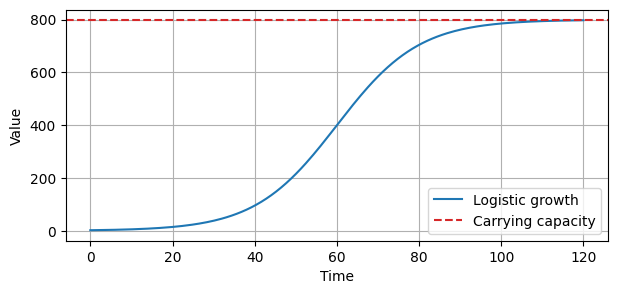

In [6]:
plt.figure(figsize=(7, 3))
plt.plot(t, y, label='Logistic growth')
plt.xlabel('Time')
plt.ylabel('Value')
plt.axhline(C, color='tab:red', linestyle='--', label='Carrying capacity')
plt.legend()
plt.grid(True)
plt.show()

**🛠️ Попробуйте сами**

- Попробуйте установить `m=20`, чтобы увидеть, как изменится кривая.

- Также попробуйте изменить значения `k` и `C`.

### Компонент сезонности $s(t)$

Компонент сезонности $s(t)$ моделирует периодические изменения, которые могут быть ежегодными, еженедельными или ежедневными.

Prophet использует ряды Фурье для моделирования этих периодических изменений, что обеспечивает гибкость в учете сезонности.

$$s(t) = \sum_{n=1}^{N} \left(a_n \cos\left(\frac{2\pi n t}{P}\right) + b_n \sin\left(\frac{2\pi n t}{P}\right)\right)$$

где:
- $N$ — количество членов Фурье (большее $N$ позволяет уловить более детальные сезонные закономерности),
- $P$ — период (например, 365,25 для годовой сезонности),
- $a_n$ и $b_n$ — коэффициенты рядов Фурье, подобранные к данным.

### Праздники и события $h(t)$

- Компонент праздников $h(t)$ моделирует нерегулярные, но предсказуемые события.

- Этот компонент представлен в виде ряда индикаторных функций, равных 1, если время $t$ соответствует празднику, и 0 в противном случае.

- Коэффициенты, связанные с этими индикаторами, подбираются для измерения влияния праздников на прогноз.

Праздничная составляющая $h(t)$ определяется как

$$h(t) = \sum_{i} I(t \in D_i) \cdot \delta_i$$

где:
- $D_i$ представляет собой множество временных интервалов, соответствующих празднику $i$,
- $I$ — индикаторная функция,
- $\delta_i$ — влияние праздника $i$ на временной ряд, которое можно настраивать.

#### Коррекция сезонных и праздничных эффектов

- Как и в случае с кусочно-линейным трендом, Prophet может корректировать переобучение или недообучение при сезонных и праздничных эффектах, изменяя *масштаб априорного распределения* этих компонентов.

- *Больший* масштаб априорного распределения позволяет модели учитывать более значительные сезонные колебания.

- *Меньший* масштаб регуляризует модель, предотвращая переобучение при сезонных и праздничных эффектах.

---

## Fitting the Model

- Описанные выше компоненты объединены в общую модель.

- Для подгонки модели Prophet к историческим данным параметры модели оцениваются с использованием метода максимального правдоподобия или байесовской выборки.

- Это включает оптимизацию параметров для минимизации разницы между наблюдаемыми и прогнозируемыми значениями временного ряда.

- Оптимизация обычно выполняется с помощью методов градиентного спуска.

- Для выполнения оптимизации Prophet использует [Stan](https://mc-stan.org/), библиотеку C++ для статистического моделирования и высокопроизводительных статистических вычислений, которая делает подгонку модели очень быстрой.

--

## Prophet in Python

- Входными данными для Prophet всегда является датафрейм с двумя столбцами: `ds` и `y`.

- Обязательно переименуйте свой датафрейм, используя эти имена столбцов.

- Столбец `ds` (дата) должен иметь формат, ожидаемый Pandas, в идеале YYYY-MM-DD для даты или YYYY-MM-DD HH:MM:SS для временной метки.

- Столбец `y` должен быть числовым и представлять собой измерение, которое мы хотим спрогнозировать.

— В качестве примера рассмотрим временной ряд ежедневных просмотров страницы в Википедии о [Пейтоне Мэннинге](https://en.wikipedia.org/wiki/Peyton_Manning), бывшем футболисте.

— Это хороший пример, поскольку он иллюстрирует некоторые функции Prophet, такие как множественная сезонность, изменяющиеся темпы роста и возможность моделирования особых дней (например, выступлений Мэннинга в плей-офф и Суперкубке).

In [7]:
data_path = 'https://raw.githubusercontent.com/PinkWink/DataScience/master/data/07.%20example_wp_peyton_manning.csv'
peyton = pd.read_csv(data_path)
peyton.head()

,ds,y
0,2007-12-10,14629
1,2007-12-11,5012
2,2007-12-12,3582
3,2007-12-13,3205
4,2007-12-14,2680


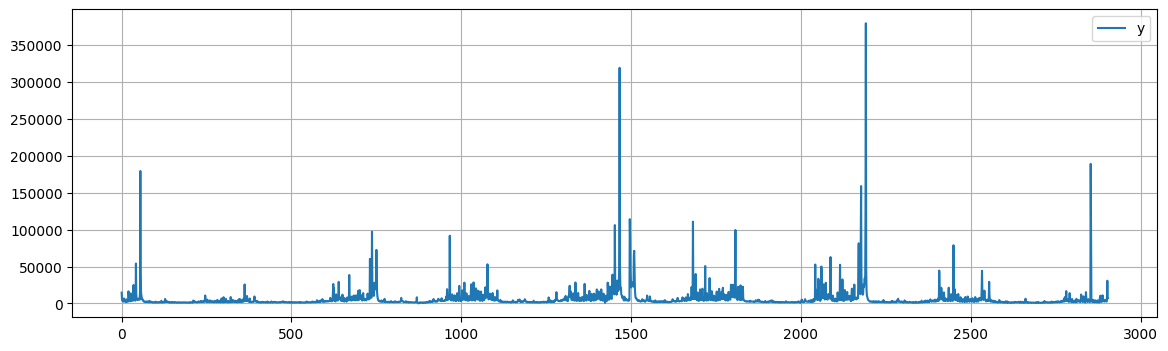

In [8]:
peyton.plot(figsize=(14, 4), grid=True);

Поскольку в данных наблюдаются значительные всплески, мы применим логарифмическое преобразование, чтобы получить более равномерный диапазон вариаций в данных.

In [9]:
peyton['y'] = np.log(peyton['y'])
peyton.head()

,ds,y
0,2007-12-10,9.590761
1,2007-12-11,8.519590
2,2007-12-12,8.183677
3,2007-12-13,8.072467
4,2007-12-14,7.893572


— Логарифмическое преобразование явно стабилизировало дисперсию данных, как видно из графика.

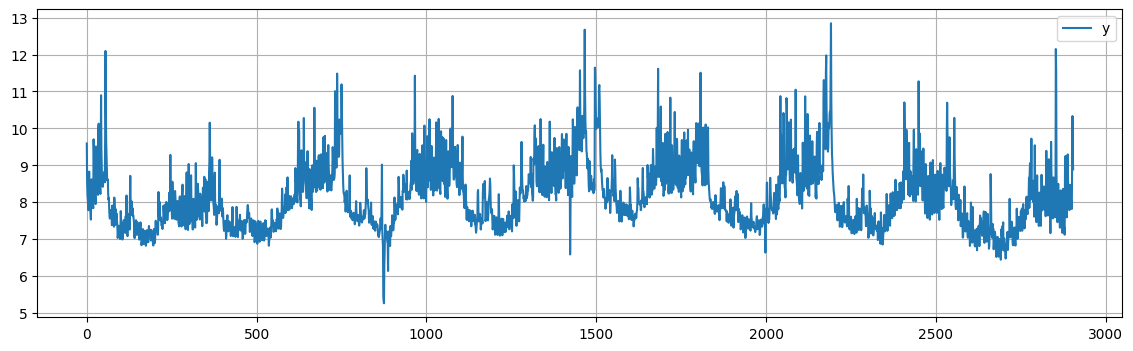

In [10]:
peyton.plot(figsize=(14, 4), grid=True);

— Далее мы создаём новый объект Prophet.

— Мы можем указать несколько параметров, таких как:

— `growth='linear'`, что означает использование кусочно-линейной функции для моделирования тренда. Другие варианты — `'logistic'` или `'flat'` для указания логистического или плоского тренда соответственно.

— `seasonality_mode='additive'`. Другой вариант — `'multiplicative'`.

— `interval_width=0.90` задаёт ширину интервалов неопределённости для прогноза.

In [11]:
model = Prophet(growth='linear', seasonality_mode='additive', interval_width=0.90)

- После создания экземпляра модели мы вызываем её метод `fit` и передаём ему исторический датафрейм.

- Подгонка модели должна занять 1-2 секунды.

In [12]:
model.fit(peyton);

00:42:06 - cmdstanpy - INFO - Chain [1] start processing
00:42:07 - cmdstanpy - INFO - Chain [1] done processing


- Затем прогнозы делаются на основе датафрейма со столбцом `ds`, содержащим даты, для которых должен быть сделан прогноз.

- Вы можете получить подходящий датафрейм, простирающийся в будущее на указанное количество дней, используя вспомогательный метод `Prophet.make_future_dataframe`.

- `periods=365` задает длину нашего прогноза.

- `freq='D'` указывает, что единицы измерения (в данном случае `365`) представляют дни.

- Установив `include_history=True`, мы также сможем увидеть даты, использованные для обучения.

In [13]:
future = model.make_future_dataframe(periods=365, freq='D', include_history=True)
future.tail()

,ds
3265,2017-01-15
3266,2017-01-16
3267,2017-01-17
3268,2017-01-18
3269,2017-01-19


- Метод `predict` присвоит каждой строке в `future` прогнозируемое значение `yhat`.

- Указав также исторические даты (`include_history=True`), он обеспечит соответствие внутри выборки.

- Объект `forecast` здесь представляет собой новый датафрейм, который включает столбец `yhat` с прогнозом и множество других столбцов, в том числе с интервалами неопределенности.

In [14]:
forecast = model.predict(future)
forecast.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
3265,2017-01-15,7.183227,7.295159,9.177680,6.671512,7.714249,1.018486,1.018486,1.018486,0.048286,0.048286,0.048286,0.970200,0.970200,0.970200,0.0,0.0,0.0,8.201714
3266,2017-01-16,7.182193,7.640116,9.418755,6.668937,7.714689,1.344507,1.344507,1.344507,0.352285,0.352285,0.352285,0.992222,0.992222,0.992222,0.0,0.0,0.0,8.526700
3267,2017-01-17,7.181159,7.410205,9.321642,6.666361,7.716251,1.132928,1.132928,1.132928,0.119629,0.119629,0.119629,1.013299,1.013299,1.013299,0.0,0.0,0.0,8.314087
3268,2017-01-18,7.180125,7.187843,9.099835,6.663785,7.717811,0.966582,0.966582,0.966582,-0.066648,-0.066648,-0.066648,1.033229,1.033229,1.033229,0.0,0.0,0.0,8.146706
3269,2017-01-19,7.179091,7.211789,9.095430,6.661209,7.719370,0.979489,0.979489,0.979489,-0.072278,-0.072278,-0.072278,1.051767,1.051767,1.051767,0.0,0.0,0.0,8.158580


— Вы можете построить график прогноза, вызвав метод `Prophet.plot` и передав в него фрейм данных `forecast`.

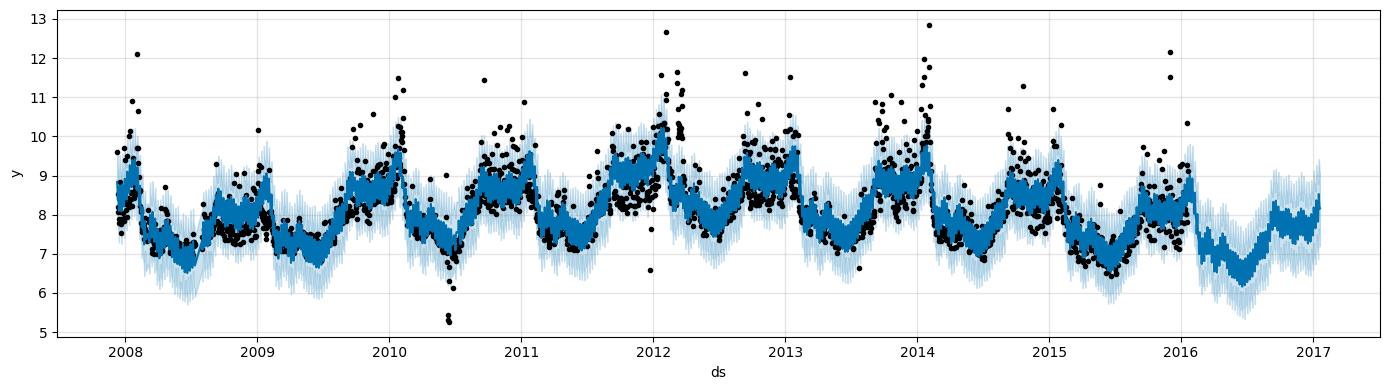

In [15]:
fig1 = model.plot(forecast, figsize=(14, 4))

- Если вы хотите увидеть компоненты прогноза, вы можете использовать метод `Prophet.plot_components`.

- По умолчанию вы увидите тренд, годовую сезонность и недельную сезонность временного ряда.

- Если вы включите праздники, вы также увидите их здесь.

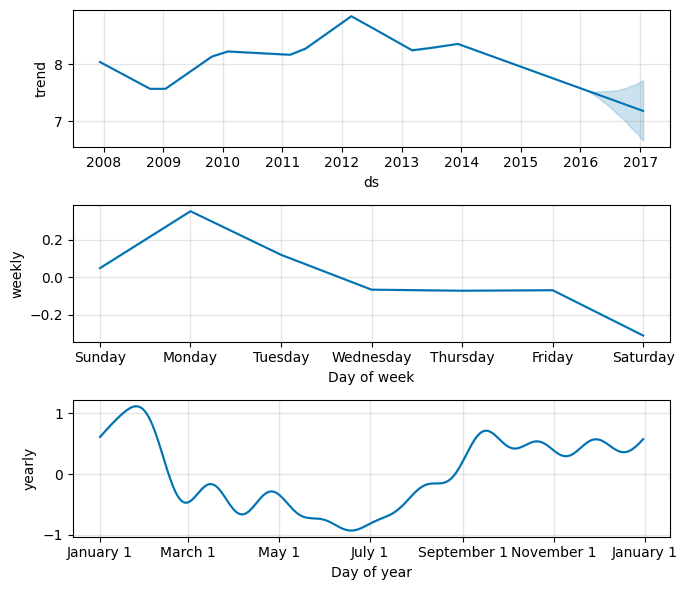

In [16]:
fig2 = model.plot_components(forecast, figsize=(7, 6))

Интерактивное отображение прогноза и его компонентов можно создать с помощью `plotly`:

```python
from prophet.plot import plot_plotly, plot_components_plotly

plot_plotly(model, forecast)
plot_components_plotly(model, forecast)
```

### Моделирование праздников и особых событий

- Если у вас есть праздники или другие повторяющиеся события, которые вы хотели бы смоделировать, необходимо создать для них фрейм данных.

- Он должен содержать два столбца («праздник» и «ds») и строку для каждого случая праздника.

- Он должен включать все случаи праздника, как в прошлом (начиная с исторических данных), так и в будущем (начиная с прогнозируемого периода).

- Если они не повторятся в будущем, Prophet смоделирует их и не включит в прогноз.

— Вы также можете добавить столбцы `lower_window` и `upper_window`, которые расширяют период праздника на [`lower_window`, `upper_window`] дней вокруг даты.

— Например, если вы хотите включить Сочельник в дополнение к Рождеству, вы добавите `'lower_window': -1` и `'upper_window': 0`.

Здесь мы создаём датафрейм, который включает даты всех выступлений Пейтона Мэннинга в плей-офф:

In [17]:
# add holidays
playoffs = pd.DataFrame({
  'holiday': 'playoff',
  'ds': pd.to_datetime(['2008-01-13', '2009-01-03', '2010-01-16',
                        '2010-01-24', '2010-02-07', '2011-01-08',
                        '2013-01-12', '2014-01-12', '2014-01-19',
                        '2014-02-02', '2015-01-11', '2016-01-17',
                        '2016-01-24', '2016-02-07']),
  'lower_window': 0, # this specifies spillover into previous days
  'upper_window': 1, # this for the future days
})

superbowls = pd.DataFrame({
  'holiday': 'superbowl',
  'ds': pd.to_datetime(['2010-02-07', '2014-02-02', '2016-02-07']),
  'lower_window': 0,
  'upper_window': 1,
})

holidays_df = pd.concat((playoffs, superbowls))

— Выше мы включили дни Супербоула как игры плей-офф, так и игры Супербоула.

— Это означает, что эффект Супербоула будет дополнительным бонусом к эффекту плей-офф.

После создания объекта `holidays_df`, влияние праздников включается в прогноз путем передачи этих данных в качестве аргумента `holidays` конструктора.

In [18]:
# fit and predict
model_holyday = Prophet(holidays=holidays_df, # this includes the holidays
                        growth='linear', seasonality_mode='additive', interval_width=0.90) # these are unchanged
forecast = model_holyday.fit(peyton).predict(future)

00:42:09 - cmdstanpy - INFO - Chain [1] start processing
00:42:09 - cmdstanpy - INFO - Chain [1] done processing


Мы можем наблюдать влияние различных праздников на посещаемость объектов.

In [19]:
forecast[(forecast['playoff'] + forecast['superbowl']).abs() > 0][
        ['ds', 'yhat', 'playoff', 'superbowl']][-10:]

,ds,yhat,playoff,superbowl
2190,2014-02-02,11.627604,1.219253,1.200554
2191,2014-02-03,12.845866,1.896023,1.466129
2532,2015-01-11,9.882314,1.219253,0.000000
2533,2015-01-12,10.891084,1.896023,0.000000
2901,2016-01-17,9.641513,1.219253,0.000000
2902,2016-01-18,10.653031,1.896023,0.000000
2908,2016-01-24,9.777818,1.219253,0.000000
2909,2016-01-25,10.779908,1.896023,0.000000
2922,2016-02-07,10.695894,1.219253,1.200554
2923,2016-02-08,11.887668,1.896023,1.466129


Мы также можем визуально оценить влияние праздников.

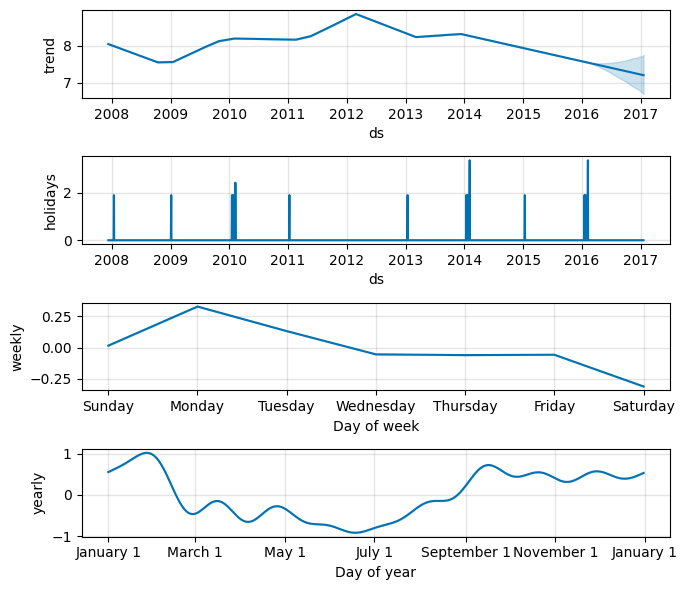

In [20]:
fig2 = model_holyday.plot_components(forecast, figsize=(7, 6))

- Теперь `plot_components` содержит также компонент праздников.

- Пейтон выиграл Супербоул в 2016 году, проиграв в 2010 и 2014 годах.
- Мы можем увидеть эти всплески на графике праздников.

- Вы можете использовать встроенную коллекцию праздников для каждой страны, используя `add_country_holidays`.

- Указывается название страны, и затем основные праздники этой страны будут включены в дополнение к любым праздникам, указанным с помощью аргумента holidays, описанного ранее.

- Список доступных стран и код страны доступен [здесь](https://github.com/vacanza/python-holidays/).

In [21]:
model_holyday2 = Prophet(holidays=holidays_df) # this includes the holidays we specified by hand
model_holyday2.add_country_holidays(country_name='US') # this the contruy-specific holidays
model_holyday2.fit(peyton)
print(model_holyday2.train_holiday_names)

00:42:11 - cmdstanpy - INFO - Chain [1] start processing
00:42:11 - cmdstanpy - INFO - Chain [1] done processing


0                         playoff
1                       superbowl
2                  New Year's Day
3                    Memorial Day
4                Independence Day
5                       Labor Day
6                Thanksgiving Day
7                   Christmas Day
8        Christmas Day (observed)
9      Martin Luther King Jr. Day
10          Washington's Birthday
11                   Columbus Day
12                   Veterans Day
13        Veterans Day (observed)
14    Independence Day (observed)
15      New Year's Day (observed)
dtype: object


Как и прежде, праздники на уровне стран будут отображаться на графике компонентов.

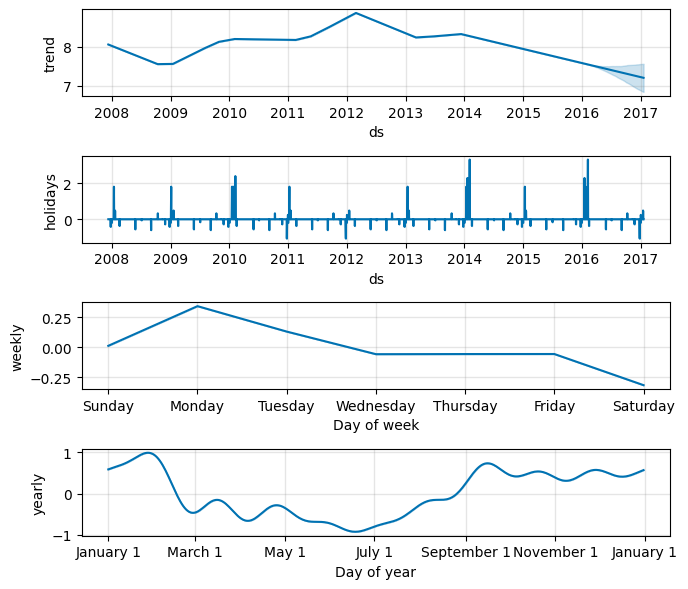

In [22]:
forecast = model_holyday2.predict(future)
fig = model_holyday2.plot_components(forecast, figsize=(7, 6))

### Прогнозирование насыщения

- Как обсуждалось ранее, Prophet позволяет делать прогнозы, используя модель логистического роста.

- Здесь мы будем использовать [пакет Datasets](https://www.statsmodels.org/stable/datasets/index.html) из `statsmodels`.

- Список доступных наборов данных находится [здесь](https://vincentarelbundock.github.io/Rdatasets/articles/data.html).

- Перед использованием данных нам потребуется выполнить некоторую предварительную обработку.

In [23]:
co2 = sm.datasets.get_rdataset("CO2", "datasets").data
print(co2.head())

          time   value
0  1959.000000  315.42
1  1959.083333  316.31
2  1959.166667  316.50
3  1959.250000  317.56
4  1959.333333  318.13


In [24]:
# Convert decimal year to pandas datetime
def convert_decimal_year_to_datetime(decimal_years):
    dates = [(pd.to_datetime(f'{int(year)}-01-01') + pd.to_timedelta((year - int(year)) * 365.25, unit='D')).date()
             for year in decimal_years]
    return dates

# Convert to Prophet format
co2['time'] = convert_decimal_year_to_datetime(co2['time'])
co2.rename(columns={'time': 'ds', 'value': 'y'}, inplace=True)

# Convert the column ds to datetime
co2['ds'] = pd.to_datetime(co2['ds'])
print("\nConverted:\n------------------\n", co2.head())


Converted:
------------------
           ds       y
0 1959-01-01  315.42
1 1959-01-31  316.31
2 1959-03-02  316.50
3 1959-04-02  317.56
4 1959-05-02  318.13


In [25]:
# Resample to monthly frequency based on the ds column
co2 = co2.resample('MS', on='ds').mean().reset_index()

# Replace NaN with the mean of the previous and next value
co2['y'] = co2['y'].interpolate()
print("\nResampled:\n------------------\n", co2.head())


Resampled:
------------------
           ds         y
0 1959-01-01  315.8650
1 1959-02-01  316.1825
2 1959-03-01  316.5000
3 1959-04-01  317.5600
4 1959-05-01  318.1300


Далее мы разделяем данные на обучающую выборку (первые 90% данных) и тестовую выборку (оставшиеся 10%).

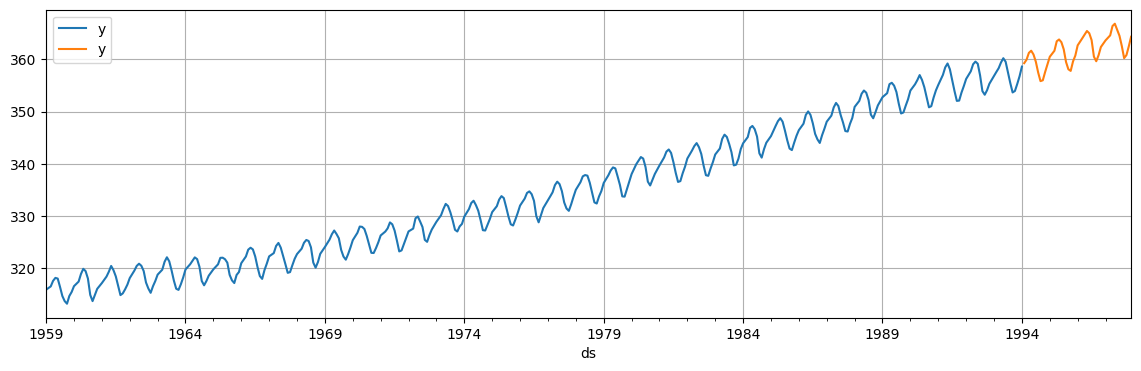

In [26]:
# Note that we need to make a copy here since we will modify the data
train = co2.iloc[:int(co2.shape[0] * 0.9)].copy()
test = co2.iloc[int(co2.shape[0] * 0.9):].copy()

fig, ax = plt.subplots(figsize=(10, 4))
train.plot(x='ds', y='y', figsize=(14, 4), grid=True, ax=ax)
test.plot(x='ds', y='y', figsize=(14, 4), grid=True, ax=ax)
plt.show()

- Логистическая модель требует указания предельной численности населения, т. е. максимально достижимой точки (общий размер рынка, общая численность населения и т. д.).

- Предельная численность населения указывается в столбце `cap`.

- Здесь мы зададим произвольное значение, но обычно оно устанавливается на основе экспертных знаний и информации о данных.

In [27]:
train['cap'] = 360

Затем мы, как и прежде, построили модель, но изменили `growth='linear'` на `growth='logistic'`.

In [28]:
model_logist = Prophet(growth='logistic', # this has changed
                       seasonality_mode='additive', interval_width=0.90)
model_logist.fit(train);

00:42:15 - cmdstanpy - INFO - Chain [1] start processing
00:42:16 - cmdstanpy - INFO - Chain [1] done processing


- Мы создаём датафрейм для прогнозов на будущее, как и раньше, за исключением того, что нам также необходимо указать пропускную способность в будущем.

- Здесь мы устанавливаем пропускную способность на том же значении, которое мы использовали для исторических данных (`train['cap'] = 360`).

- Наконец, мы вычисляем прогноз для дат в тестовом наборе.

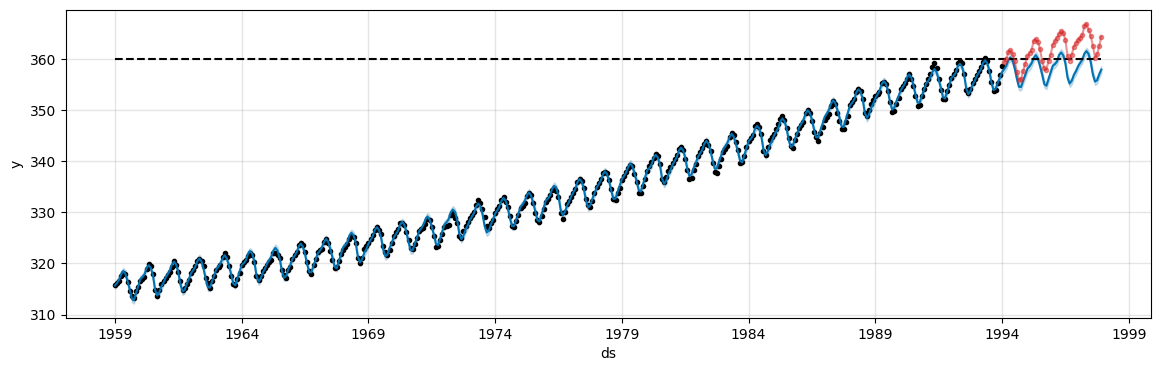

In [29]:
future = future = pd.DataFrame({'ds': pd.concat([train['ds'], test['ds']])}) # Init df for predictions
future['cap'] = 360                                                          # Set the cap
fcst = model_logist.predict(future)                                          # Compute forecasts
fig, ax = plt.subplots(figsize=(14, 4))
fig = model_logist.plot(fcst, ax=ax)
ax.plot(test['ds'], test['y'], 'tab:red', marker='o', markersize=3, alpha=0.5);

- Модель пытается удерживать прогнозы в пределах указанного значения `cap`.

- В данном случае это значение явно слишком низкое. Попробуйте использовать `cap=380` для получения более точных прогнозов.

- Модель логистического роста также может учитывать минимум насыщения.

- Он задается столбцом `floor` аналогично столбцу `cap`, который задает максимум.

- Для использования тренда логистического роста с минимумом насыщения необходимо также указать максимальную пропускную способность.

00:42:16 - cmdstanpy - INFO - Chain [1] start processing
00:42:16 - cmdstanpy - INFO - Chain [1] done processing


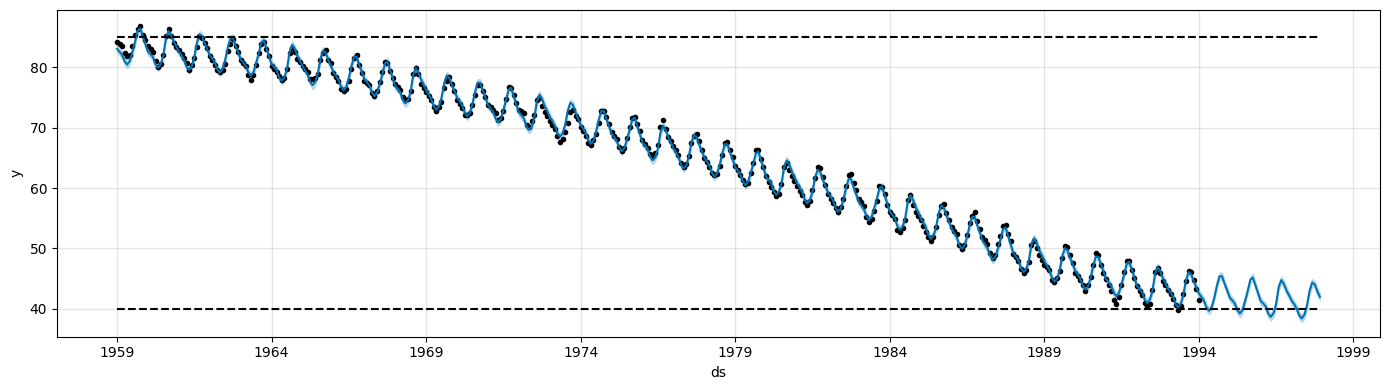

In [30]:
train['y'] = 400 - train['y'] # Modify the data so that the time series decreases over time
train['cap'] = 85
train['floor'] = 40
future['cap'] = 85
future['floor'] = 40
m = Prophet(growth='logistic')
m.fit(train)
fcst = m.predict(future)
fig = m.plot(fcst, figsize=(14, 4))

### Точки изменения тренда

- В реальных временных рядах часто наблюдаются резкие изменения траектории.

- По умолчанию Prophet автоматически обнаруживает эти точки изменения и позволяет тренду соответствующим образом адаптироваться.

- Однако, если вы хотите более точно контролировать этот процесс (например, Prophet пропустил изменение темпа или переобучается на изменениях темпа в истории), то вы можете использовать несколько входных аргументов.

- Prophet обнаруживает точки изменения, сначала указывая большое количество потенциальных точек изменения, в которых допускается изменение скорости.

- Благодаря L1-регуляризации, которая способствует разреженности, он использует как можно меньше таких точек.

- Давайте снова рассмотрим данные по Пейтону Мэннингу.

In [31]:
# Data already log-transformed
df = pd.read_csv('https://raw.githubusercontent.com/facebook/prophet/main/examples/example_wp_log_peyton_manning.csv')
m = Prophet()
m.fit(df)
future = m.make_future_dataframe(periods=365)
forecast = m.predict(future)

00:42:18 - cmdstanpy - INFO - Chain [1] start processing
00:42:18 - cmdstanpy - INFO - Chain [1] done processing


- Prophet указывает 25 *потенциальных точек изменения*, которые равномерно распределены в первых 80% временного ряда.

- Вертикальные линии показывают, где были расположены потенциальные точки изменения.

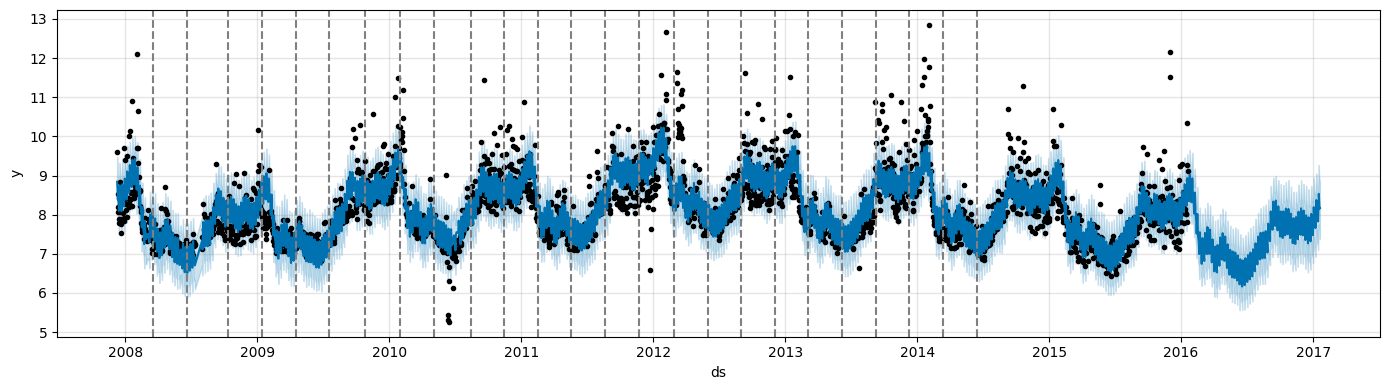

In [32]:
from prophet.plot import add_changepoints_to_plot
fig = m.plot(forecast, figsize=(14, 4))
a = add_changepoints_to_plot(fig.gca(), m, forecast, threshold=0.0, cp_color='gray', trend=False)

— Несмотря на то, что у нас много мест, где скорость может измениться, из-за разреженного априорного распределения большинство этих точек изменения не используются.

— Мы можем увидеть это, построив график величины изменения скорости в каждой точке изменения.

— Мы оставляем только те точки, где величина изменения скорости значительна.

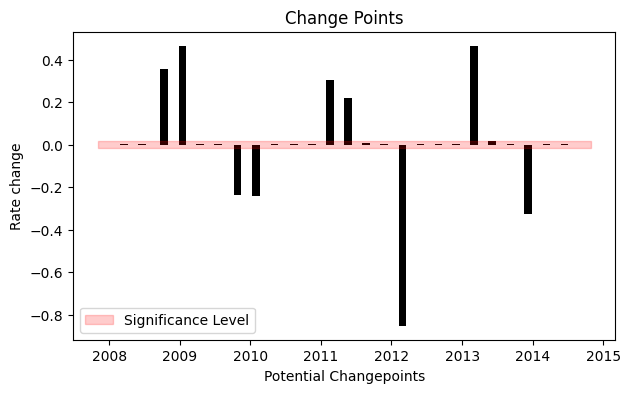

In [33]:
fig, ax = plt.subplots(figsize=(7, 4))
eps = 5e-3  # small offset to improve visualization
ax.bar(m.changepoints, np.nanmean(m.params['delta'], axis=0)+eps, color='k', width=40)
ax.fill_between(ax.get_xlim(), 0.01+eps, -0.01-eps, color='r', alpha=0.2, label='Significance Level')
ax.set_title('Change Points')
ax.set_ylabel('Rate change')
ax.set_xlabel('Potential Changepoints')
plt.legend()
plt.show()

- Фактически сохраняются только 9 из 25 потенциальных точек изменения.

- Мы можем визуализировать их на реальных данных.

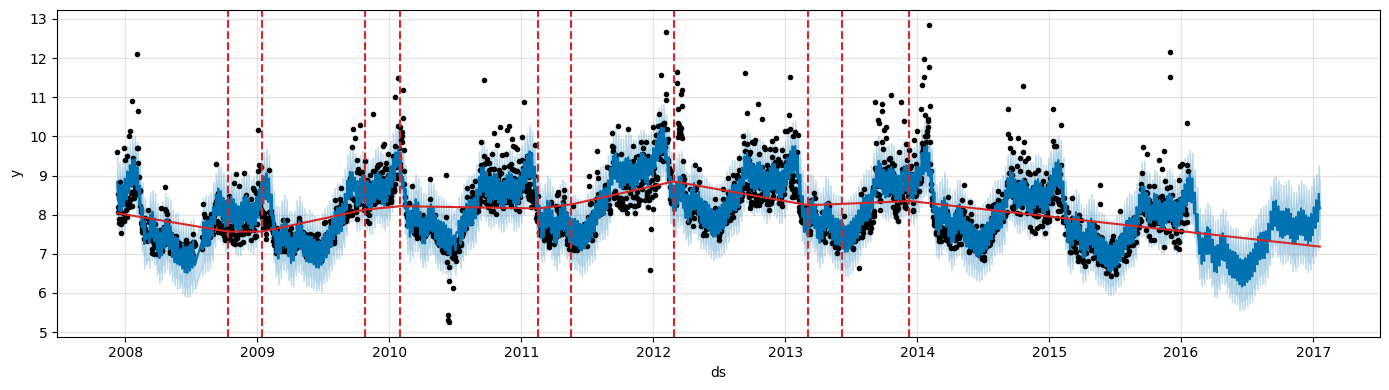

In [34]:
fig = m.plot(forecast, figsize=(14, 4))
a = add_changepoints_to_plot(fig.gca(), m, forecast, threshold=0.01, cp_color='tab:red', trend=True)

- По умолчанию точки изменения определяются только для первых 80% временного ряда.

- Это позволяет иметь достаточный запас для прогнозирования тренда и избежать переобучения на флуктуациях в конце временного ряда.

- Этот параметр по умолчанию работает во многих ситуациях, но не во всех, и его можно изменить с помощью аргумента `changepoint_range`.

- Например, `m = Prophet(changepoint_range=0.9)` разместит потенциальные точки изменения в первых 90% временного ряда.

- Это может быть полезно в ситуациях, когда к концу временного ряда происходят важные изменения тренда.

#### Регулировка гибкости тренда

- Если изменения тренда переобучаются (слишком большая гибкость) или недообучаются (недостаточная гибкость), вы можете отрегулировать силу априорного распределения разреженности, используя входной аргумент `changepoint_prior_scale`.

- По умолчанию этот параметр установлен на 0,05.

- Увеличение этого значения сделает тренд более гибким.

00:42:19 - cmdstanpy - INFO - Chain [1] start processing
00:42:20 - cmdstanpy - INFO - Chain [1] done processing


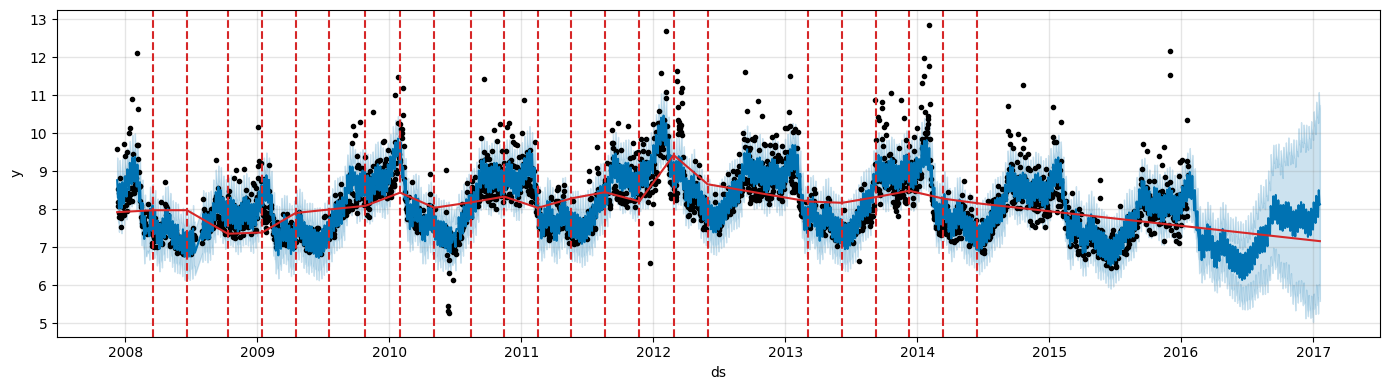

In [35]:
m = Prophet(changepoint_prior_scale=0.5) # Increase prior
forecast = m.fit(df).predict(future)
fig = m.plot(forecast, figsize=(14, 4))
a = add_changepoints_to_plot(fig.gca(), m, forecast, threshold=0.01, cp_color='tab:red', trend=True)

Снижение этого показателя сделает тенденцию менее гибкой.

00:42:21 - cmdstanpy - INFO - Chain [1] start processing
00:42:21 - cmdstanpy - INFO - Chain [1] done processing


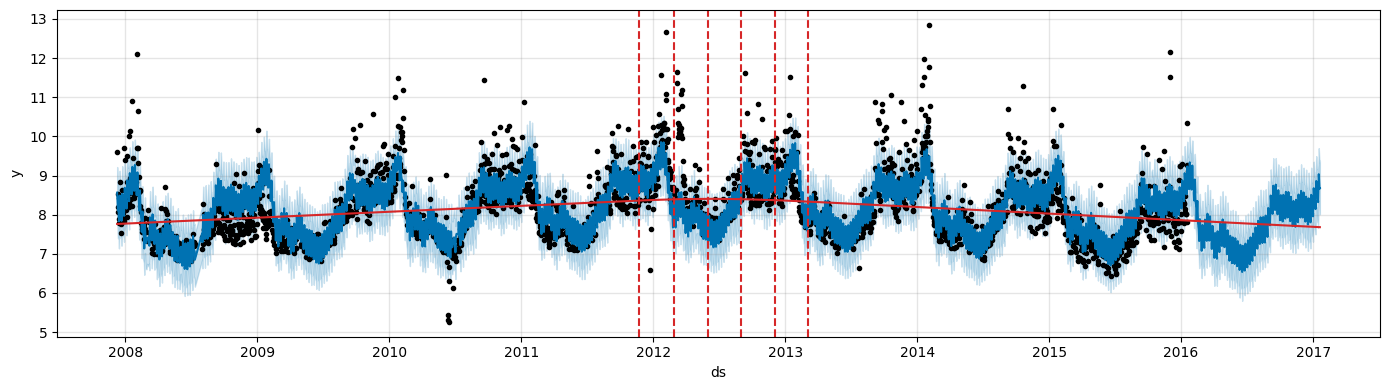

In [36]:
m = Prophet(changepoint_prior_scale=0.001) # Decrease prior
forecast = m.fit(df).predict(future)
fig = m.plot(forecast, figsize=(14, 4))
a = add_changepoints_to_plot(fig.gca(), m, forecast, threshold=0.01, cp_color='tab:red', trend=True)

#### Указание местоположения точек изменения

- Вы можете вручную указать местоположение потенциальных точек изменения с помощью аргумента `changepoints`.

- Изменения наклона будут разрешены только в этих точках с той же разреженной регуляризацией, что и раньше.

- Например, можно автоматически создать сетку точек.

- Затем дополнить сетку некоторыми конкретными датами, которые, как известно, с большой вероятностью будут иметь изменения.

- В качестве альтернативы, точки изменения могут быть полностью ограничены небольшим набором дат, как это сделано здесь.

00:42:22 - cmdstanpy - INFO - Chain [1] start processing
00:42:22 - cmdstanpy - INFO - Chain [1] done processing


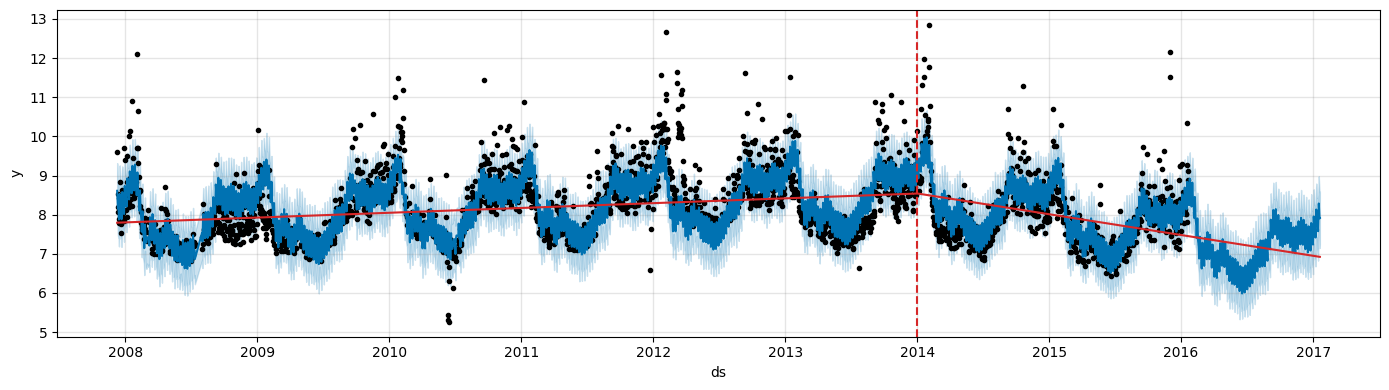

In [37]:
m = Prophet(changepoints=['2014-01-01'])
forecast = m.fit(df).predict(future)
fig = m.plot(forecast, figsize=(14, 4))
a = add_changepoints_to_plot(fig.gca(), m, forecast, threshold=0.01, cp_color='tab:red', trend=True)

---

## Краткое описание

- Методология Prophet предлагает гибкий и интуитивно понятный подход к прогнозированию временных рядов.

- Разлагая временной ряд на компоненты тренда, сезонности и праздников, она выявляет различные закономерности в данных.

- Использование рядов Фурье для сезонности и логистического или кусочно-линейного роста для тренда позволяет Prophet обрабатывать широкий спектр сценариев прогнозирования.

--

## Упражнения

Рассмотрим временной ряд ежемесячного индекса розничных продаж в Нидерландах с 1960 по 1995 год.

In [38]:
sales = sm.datasets.get_rdataset("DutchSales", "AER").data
print("Raw data:\n------------------\n", sales.head())

Raw data:
------------------
           time  value
0  1960.333333     14
1  1960.416667     13
2  1960.500000     15
3  1960.583333     13
4  1960.666667     13


1. Выполните необходимую предварительную обработку и преобразуйте данные в формат Prophet.

2. Разделите данные на обучающую и тестовую выборки, используя первые 90% и последние 10% временного ряда соответственно.

3. Постройте модель Prophet на основе данных с использованием линейного тренда и сделайте прогноз на период тестовых данных.

4. Сделайте прогноз с помощью модели, включающей национальные праздники.

5. Скорректируйте тренд, изменив параметры `changepoint_range` и `changepoint_prior_scale`. Для каждого параметра попробуйте как минимум два разных значения, отличных от значений по умолчанию.

6. Сделайте прогнозы с помощью модели с логистическим трендом.

7. Сравните производительность моделей, полученных на шагах 3-6, по показателям MSE и MAPE на тестовых данных.

In [39]:
def decimal_year_to_date(decimal_year):
    year = int(decimal_year)
    remainder = decimal_year - year
    # Преобразуем остаток в дни (учитывая високосные годы)
    days_in_year = 366 if pd.Timestamp(year, 12, 31).is_leap_year else 365
    day_of_year = int(remainder * days_in_year)
    date = pd.Timestamp(str(year)) + pd.Timedelta(days=day_of_year)
    return date

In [40]:
sales['ds'] = sales['time'].apply(decimal_year_to_date)
sales['y'] = sales['value']

sales = sales[['ds', 'y']].sort_values('ds').reset_index(drop=True)
sales

,ds,y
0,1960-05-01,14
1,1960-06-01,13
2,1960-07-02,15
3,1960-08-01,13
4,1960-09-01,13
...,...,...
420,1995-05-02,114
421,1995-06-02,116
422,1995-07-02,107
423,1995-08-01,106


In [41]:
train_size = int(len(sales) * 0.9)
train = sales.iloc[:train_size].copy()
test = sales.iloc[train_size:].copy()

print(f"Размер обучающей выборки: {len(train)}, Размер тестовой: {len(test)}")
print(f"Период обучения: {train['ds'].min()} - {train['ds'].max()}")
print(f"Период тестирования: {test['ds'].min()} - {test['ds'].max()}")

Размер обучающей выборки: 382, Размер тестовой: 43
Период обучения: 1960-05-01 00:00:00 - 1992-01-31 00:00:00
Период тестирования: 1992-03-02 00:00:00 - 1995-09-01 00:00:00


In [42]:
model_linear = Prophet()
model_linear.fit(train)

future_linear = model_linear.make_future_dataframe(periods=len(test), freq='MS')
forecast_linear = model_linear.predict(future_linear)

test_pred_linear = pd.merge(
    test[['ds']], 
    forecast_linear[['ds', 'yhat']], 
    on='ds', 
    how='left'
)

00:42:25 - cmdstanpy - INFO - Chain [1] start processing
00:42:25 - cmdstanpy - INFO - Chain [1] done processing


In [43]:
model_holidays = Prophet()
model_holidays.add_country_holidays(country_name='NL')
model_holidays.fit(train)

future_holidays = model_holidays.make_future_dataframe(periods=len(test), freq='MS')
forecast_holidays = model_holidays.predict(future_holidays)

test_pred_holidays = pd.merge(
    test[['ds']], 
    forecast_holidays[['ds', 'yhat']], 
    on='ds', 
    how='left'
)

print(f"\nПраздники, добавленные в модель ({len(model_holidays.train_holiday_names)}):")
for holiday in list(model_holidays.train_holiday_names)[:5]:
    print(f"  - {holiday}")

00:42:25 - cmdstanpy - INFO - Chain [1] start processing
00:42:25 - cmdstanpy - INFO - Chain [1] done processing



Праздники, добавленные в модель (11):
  - New Year's Day
  - Good Friday
  - Easter Sunday
  - Easter Monday
  - Queen's Day


In [44]:
model_range_06 = Prophet(changepoint_range=0.6)
model_range_06.fit(train)
forecast_range_06 = model_range_06.predict(
    model_range_06.make_future_dataframe(periods=len(test), freq='MS')
)
test_pred_range_06 = pd.merge(
    test[['ds']], 
    forecast_range_06[['ds', 'yhat']], 
    on='ds', 
    how='left'
)

00:42:26 - cmdstanpy - INFO - Chain [1] start processing
00:42:26 - cmdstanpy - INFO - Chain [1] done processing


In [45]:
model_range_095 = Prophet(changepoint_range=0.95)
model_range_095.fit(train)
forecast_range_095 = model_range_095.predict(
    model_range_095.make_future_dataframe(periods=len(test), freq='MS')
)
test_pred_range_095 = pd.merge(
    test[['ds']], 
    forecast_range_095[['ds', 'yhat']], 
    on='ds', 
    how='left'
)

00:42:26 - cmdstanpy - INFO - Chain [1] start processing
00:42:26 - cmdstanpy - INFO - Chain [1] done processing


In [46]:
model_prior_001 = Prophet(changepoint_prior_scale=0.01)
model_prior_001.fit(train)
forecast_prior_001 = model_prior_001.predict(
    model_prior_001.make_future_dataframe(periods=len(test), freq='MS')
)
test_pred_prior_001 = pd.merge(
    test[['ds']], 
    forecast_prior_001[['ds', 'yhat']], 
    on='ds', 
    how='left'
)

00:42:26 - cmdstanpy - INFO - Chain [1] start processing
00:42:26 - cmdstanpy - INFO - Chain [1] done processing


In [47]:
model_prior_05 = Prophet(changepoint_prior_scale=0.5)
model_prior_05.fit(train)
forecast_prior_05 = model_prior_05.predict(
    model_prior_05.make_future_dataframe(periods=len(test), freq='MS')
)
test_pred_prior_05 = pd.merge(
    test[['ds']], 
    forecast_prior_05[['ds', 'yhat']], 
    on='ds', 
    how='left'
)

00:42:26 - cmdstanpy - INFO - Chain [1] start processing
00:42:26 - cmdstanpy - INFO - Chain [1] done processing


In [48]:
cap_value = train['y'].max() * 1.5

train_logistic = train.copy()
train_logistic['cap'] = cap_value

model_logistic = Prophet(growth='logistic')
model_logistic.fit(train_logistic)

future_logistic = model_logistic.make_future_dataframe(periods=len(test), freq='MS')
future_logistic['cap'] = cap_value

forecast_logistic = model_logistic.predict(future_logistic)

test_pred_logistic = pd.merge(
    test[['ds']], 
    forecast_logistic[['ds', 'yhat']], 
    on='ds', 
    how='left'
)

print(f"\nЛогистическая модель с cap = {cap_value:.2f}")

00:42:27 - cmdstanpy - INFO - Chain [1] start processing
00:42:27 - cmdstanpy - INFO - Chain [1] done processing



Логистическая модель с cap = 178.50


In [49]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error

predictions = {
    'Линейный тренд': test_pred_linear['yhat'].values,
    'С праздниками NL': test_pred_holidays['yhat'].values,
    'Changepoint_range=0.6': test_pred_range_06['yhat'].values,
    'Changepoint_range=0.95': test_pred_range_095['yhat'].values,
    'Prior_scale=0.01': test_pred_prior_001['yhat'].values,
    'Prior_scale=0.5': test_pred_prior_05['yhat'].values,
    'Логистический тренд': test_pred_logistic['yhat'].values
}

actual_values = test['y'].values
results = []

print("\n" + "="*70)
print("СРАВНЕНИЕ МОДЕЛЕЙ НА ТЕСТОВЫХ ДАННЫХ")
print("="*70)

for model_name, pred_values in predictions.items():
    if np.any(np.isnan(pred_values)):
        nan_count = np.sum(np.isnan(pred_values))
        pred_values = np.nan_to_num(pred_values, nan=np.nanmean(pred_values))

    mse_value = mean_squared_error(actual_values, pred_values)
    mape_value = mean_absolute_percentage_error(actual_values, pred_values) * 100
    
    results.append({
        'Модель': model_name,
        'MSE': mse_value,
        'MAPE (%)': mape_value
    })
    
    print(f"{model_name:25} | MSE: {mse_value:10.2f} | MAPE: {mape_value:6.2f}%")


results_df = pd.DataFrame(results)
results_df = results_df.sort_values('MAPE (%)')

print("\n" + "="*70)
print("ЛУЧШИЕ МОДЕЛИ (по MAPE):")
print("="*70)
print(results_df.to_string(index=False))

best_model = results_df.iloc[0]
print(f"\nЛучшая модель: {best_model['Модель']}")
print(f"   MSE: {best_model['MSE']:.2f}")
print(f"   MAPE: {best_model['MAPE (%)']:.2f}%")


СРАВНЕНИЕ МОДЕЛЕЙ НА ТЕСТОВЫХ ДАННЫХ
Линейный тренд            | MSE:      52.45 | MAPE:   5.03%
С праздниками NL          | MSE:      51.61 | MAPE:   4.99%
Changepoint_range=0.6     | MSE:      78.34 | MAPE:   6.89%
Changepoint_range=0.95    | MSE:      83.75 | MAPE:   6.68%
Prior_scale=0.01          | MSE:      63.38 | MAPE:   5.94%
Prior_scale=0.5           | MSE:      57.89 | MAPE:   5.30%
Логистический тренд       | MSE:      52.98 | MAPE:   5.15%

ЛУЧШИЕ МОДЕЛИ (по MAPE):
                Модель       MSE  MAPE (%)
      С праздниками NL 51.610761  4.987259
        Линейный тренд 52.447904  5.026388
   Логистический тренд 52.981176  5.146088
       Prior_scale=0.5 57.892119  5.297247
      Prior_scale=0.01 63.376349  5.936401
Changepoint_range=0.95 83.752769  6.684538
 Changepoint_range=0.6 78.336047  6.887962

Лучшая модель: С праздниками NL
   MSE: 51.61
   MAPE: 4.99%


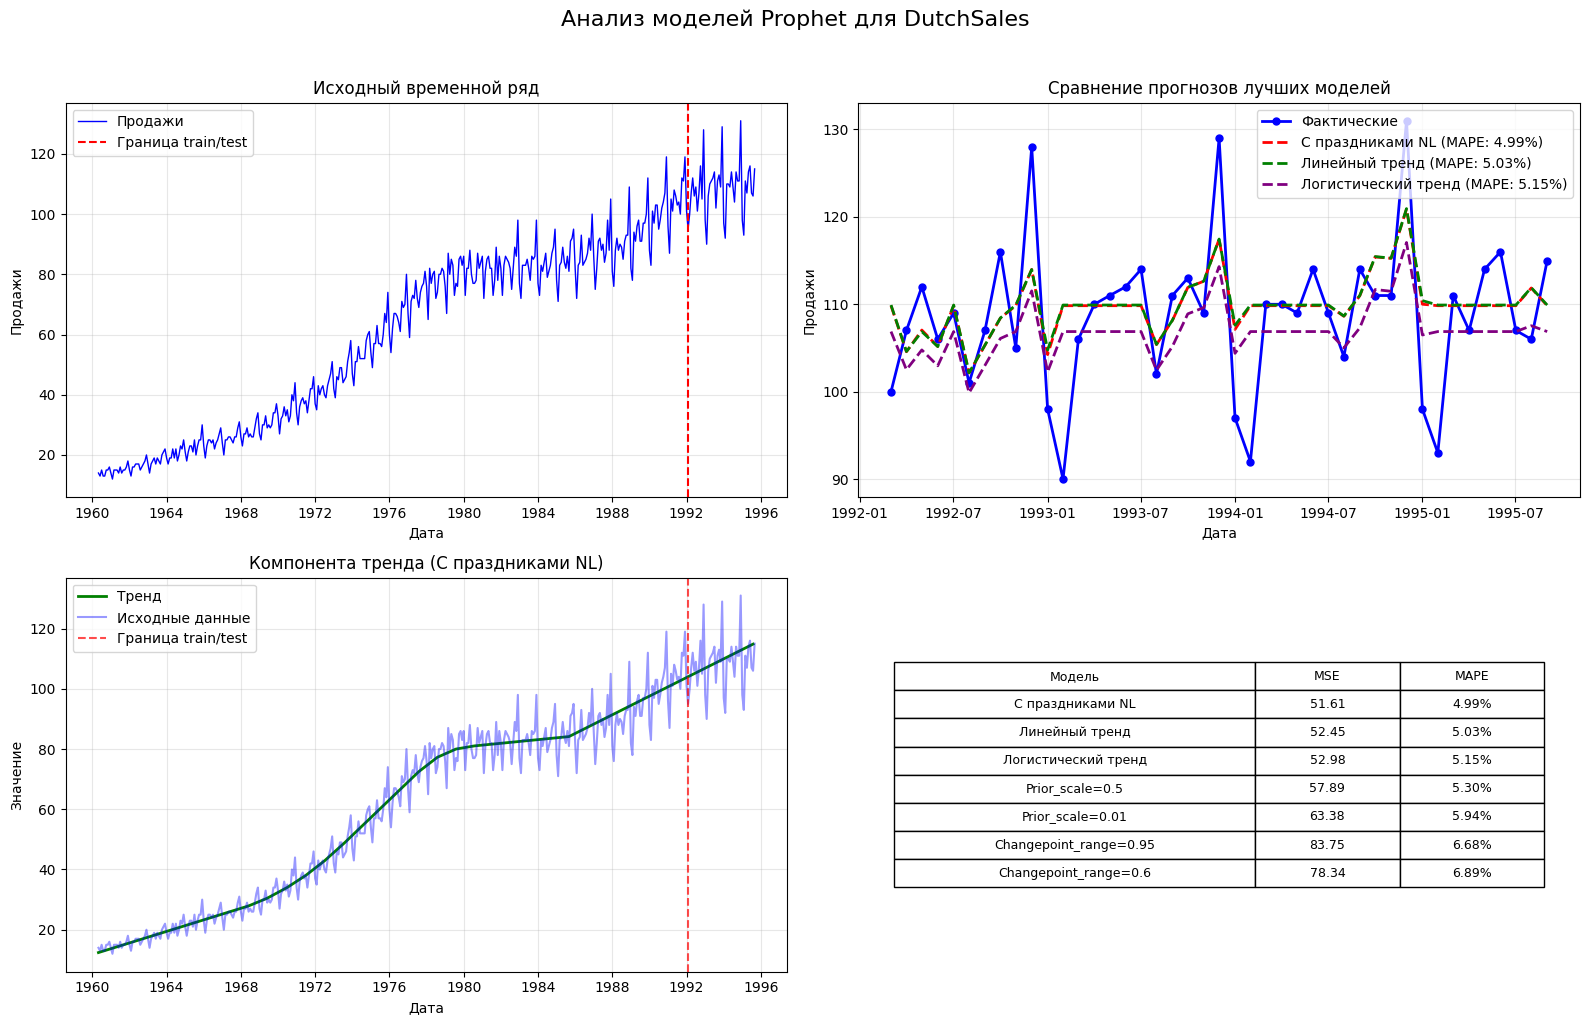

In [50]:
actual_values = test['y'].values

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

ax1 = axes[0, 0]
ax1.plot(sales['ds'], sales['y'], 'b-', linewidth=1, label='Продажи')
ax1.axvline(x=train['ds'].iloc[-1], color='r', linestyle='--', label='Граница train/test')
ax1.set_title('Исходный временной ряд')
ax1.set_xlabel('Дата')
ax1.set_ylabel('Продажи')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = axes[0, 1]
ax2.plot(test['ds'], actual_values, 'bo-', label='Фактические', linewidth=2, markersize=5)

top_models = results_df.head(3)['Модель'].tolist()
colors = ['red', 'green', 'purple']

for i, model in enumerate(top_models):
    if model in predictions:
        pred_vals = predictions[model]
        # Обработка NaN (если нужно)
        if np.any(np.isnan(pred_vals)):
            pred_vals = np.nan_to_num(pred_vals, nan=np.nanmean(pred_vals))
        mape_val = results_df[results_df['Модель'] == model]['MAPE (%)'].values[0]
        ax2.plot(test['ds'], pred_vals, '--', 
                 label=f"{model} (MAPE: {mape_val:.2f}%)",
                 color=colors[i % len(colors)], linewidth=2)

ax2.set_title('Сравнение прогнозов лучших моделей')
ax2.set_xlabel('Дата')
ax2.set_ylabel('Продажи')
ax2.legend()
ax2.grid(True, alpha=0.3)

best_model_name = best_model['Модель']

forecast_map = {
    'Линейный тренд': forecast_linear,
    'С праздниками NL': forecast_holidays,
    'Changepoint_range=0.6': forecast_range_06,
    'Changepoint_range=0.95': forecast_range_095,
    'Prior_scale=0.01': forecast_prior_001,
    'Prior_scale=0.5': forecast_prior_05,
    'Логистический тренд': forecast_logistic
}

if best_model_name in forecast_map:
    best_forecast = forecast_map[best_model_name]
else:
    raise ValueError(f"Не найден прогноз для модели: {best_model_name}")

ax3 = axes[1, 0]
ax3.plot(best_forecast['ds'], best_forecast['trend'], 'g-', label='Тренд', linewidth=2)
ax3.plot(sales['ds'], sales['y'], 'b-', alpha=0.4, label='Исходные данные')
ax3.axvline(x=train['ds'].iloc[-1], color='r', linestyle='--', alpha=0.7, label='Граница train/test')
ax3.set_title(f'Компонента тренда ({best_model_name})')
ax3.set_xlabel('Дата')
ax3.set_ylabel('Значение')
ax3.legend()
ax3.grid(True, alpha=0.3)

ax4 = axes[1, 1]
ax4.axis('tight')
ax4.axis('off')

table_data = []
for _, row in results_df.iterrows():
    table_data.append([
        row['Модель'],
        f"{row['MSE']:.2f}",
        f"{row['MAPE (%)']:.2f}%"
    ])

table = ax4.table(
    cellText=table_data,
    colLabels=['Модель', 'MSE', 'MAPE'],
    cellLoc='center',
    loc='center',
    colWidths=[0.5, 0.2, 0.2]
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.5)

plt.suptitle('Анализ моделей Prophet для DutchSales', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()